In [2]:
!pip install -q google-genai gradio pillow numpy

In [4]:
import os, shutil
shutil.copy("kaggle.json", os.path.expanduser("~/kaggle.json"))
os.chmod(os.path.expanduser("~/kaggle.json"), 0o600)

!kaggle datasets download -d ebrahimelgazar/pixel-art -p data/pixel_art --unzip
print("Done")

Dataset URL: https://www.kaggle.com/datasets/ebrahimelgazar/pixel-art
License(s): apache-2.0
100% 85.7M/85.7M [00:00<00:00, 181MB/s]

Done


Raw: (89400, 16, 16, 3)
Clean sprites: 1460


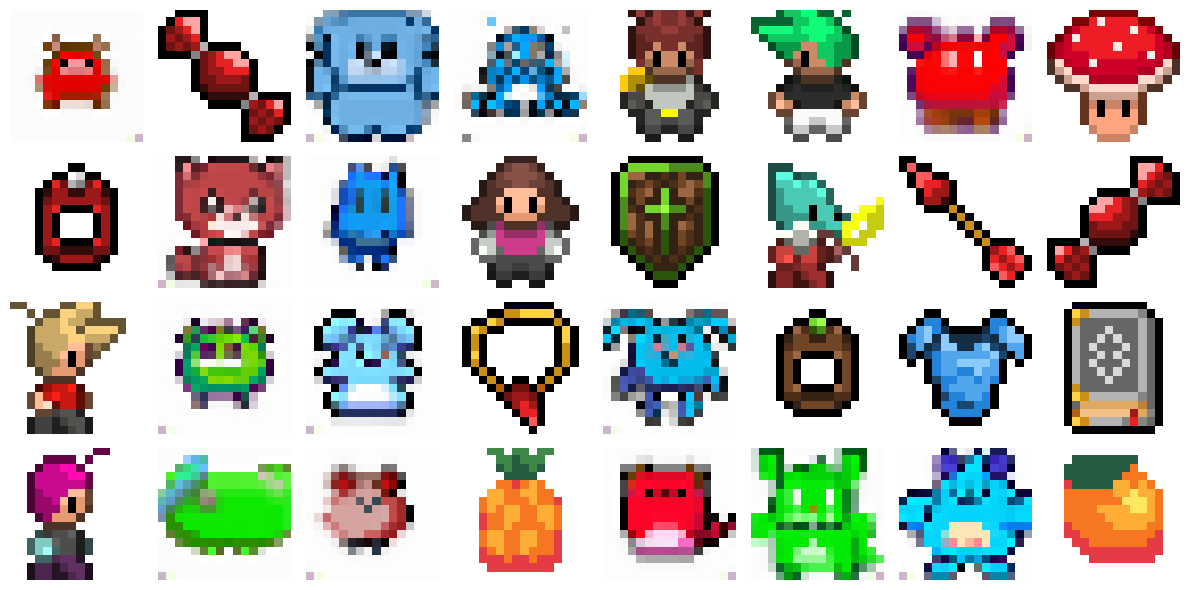

In [7]:
import numpy as np, hashlib, random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

sprites_raw = np.load("data/pixel_art/sprites.npy")
print("Raw:", sprites_raw.shape)

def is_item_sprite(sprite):
    has_alpha = sprite.shape[-1] == 4
    if has_alpha and (sprite[..., 3] > 30).mean() < 0.10:
        return False
    rgb = sprite[..., :3].astype(np.float32)
    if rgb.std() < 15.0:
        return False
    pixels = rgb.reshape(-1, 3)
    if len(np.unique((pixels / 20).astype(int), axis=0)) < 6:
        return False
    if (np.max(pixels,1) - np.min(pixels,1)).mean() < 10.0:
        return False
    return True

mask = np.array([is_item_sprite(s) for s in sprites_raw])
sprites_filtered = sprites_raw[mask]

seen, unique_idx = set(), []
for i, s in enumerate(sprites_filtered):
    h = hashlib.md5(s[..., :3].tobytes()).hexdigest()
    if h not in seen:
        seen.add(h)
        unique_idx.append(i)

sprites_clean = sprites_filtered[unique_idx]
print(f"Clean sprites: {len(sprites_clean)}")

# Preview
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
sample = random.sample(range(len(sprites_clean)), 32)
for i, ax in enumerate(axes.flat):
    ax.imshow(sprites_clean[sample[i]][..., :3], interpolation='nearest')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import io, json, requests, random, os
from PIL import Image
import numpy as np
from google import genai
from google.genai import types
from urllib.parse import quote
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=GEMINI_API_KEY)

def think_and_forge(sprite_a, sprite_b, extra=""):
    img_a = Image.fromarray(sprite_a[..., :3].astype("uint8")).resize((128, 128), Image.NEAREST)
    img_b = Image.fromarray(sprite_b[..., :3].astype("uint8")).resize((128, 128), Image.NEAREST)

    prompt = f"""You are an expert RPG item designer. I'm showing you two pixel art item sprites.
Your job:
1. Identify what each item is
2. Creatively decide what ONE new item they fuse into
3. Write a detailed image generation prompt for that fused item

Rules for the prompt:
- The output must look like a pixel art RPG game sprite/icon
- Single centered item on pure white background
- 16-bit retro game style, crisp pixels, black outline
- Be specific about colors, effects, and visual details
- Extra style notes from user: {extra}

IMPORTANT for image_prompt: must start with 'pixel art sprite, 32x32 pixelated, RPG game item icon,' and describe exact colors, shapes, and details. Emphasize: transparent or white background, single centered weapon/item, hard pixel edges, limited color palette, retro 16-bit SNES style.

Respond ONLY with valid JSON using the following keys: item_a, item_b, fused_name, reasoning, image_prompt"""

    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=[prompt, img_a, img_b],
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=0.7,
        ),
    )
    return json.loads(response.text)

def generate_image(prompt):
    """Pollinations/Flux acts as the Forge, with aggressive post-processing."""
    full_prompt = (
        f"{prompt} "
        "pixel art sprite sheet style, 16-bit SNES RPG item icon, "
        "single weapon centered, pure white background, "
        "hard pixel edges NO anti-aliasing, limited 16-color palette, "
        "retro game sprite, crisp flat colors, black pixel outline"
    )

    url = f"https://image.pollinations.ai/prompt/{quote(full_prompt)}?width=512&height=512&model=flux&seed={random.randint(0,9999)}&nologo=true"

    print("Calling Pollinations...")
    response = requests.get(url, timeout=60)
    img = Image.open(io.BytesIO(response.content)).convert("RGB")

    # Crop to square
    w, h = img.size
    m = min(w, h)
    img = img.crop(((w-m)//2, (h-m)//2, (w+m)//2, (h+m)//2))

    # Quantize to 16 colors to force pixel art palette
    img_q = img.quantize(colors=16, method=Image.Quantize.MEDIANCUT).convert("RGB")

    # Pixelate: crush to 48x48 then blow back up
    pixel_size = 48
    pixel_art = (
        img_q
        .resize((pixel_size, pixel_size), Image.NEAREST)
        .resize((512, 512), Image.NEAREST)
    )

    return pixel_art

print("Hybrid Pipeline ready.")

Hybrid Pipeline ready.


In [ ]:
import gradio as gr

N = len(sprites_clean)

def idx_to_pil(idx):
    s = sprites_clean[int(idx)][..., :3].astype("uint8")
    return Image.fromarray(s).resize((128, 128), Image.NEAREST)

def alchemize(idx_a, idx_b, extra):
    s_a = sprites_clean[int(idx_a)]
    s_b = sprites_clean[int(idx_b)]
    data = think_and_forge(s_a, s_b, extra)

    print(f"Item A: {data['item_a']}")
    print(f"Item B: {data['item_b']}")
    print(f"Fused:  {data['fused_name']}")
    print(f"Why:    {data['reasoning']}")
    print(f"Prompt: {data['image_prompt']}")

    result = generate_image(data["image_prompt"])

    label = f"**{data['fused_name']}**\n{data['reasoning']}"
    return idx_to_pil(idx_a), idx_to_pil(idx_b), result, label


with gr.Blocks(title="The Crucible", theme=gr.themes.Soft()) as demo:
    with gr.Row():
        with gr.Column():
            idx_a     = gr.Slider(0, N-1, value=0,  step=1, label="Item A")
            preview_a = gr.Image(label="Item A", height=128, width=128)
        with gr.Column():
            idx_b     = gr.Slider(0, N-1, value=10, step=1, label="Item B")
            preview_b = gr.Image(label="Item B", height=128, width=128)

    idx_a.change(fn=idx_to_pil, inputs=idx_a, outputs=preview_a)
    idx_b.change(fn=idx_to_pil, inputs=idx_b, outputs=preview_b)

    extra = gr.Textbox(value="legendary, glowing", label="Extra style notes (optional)")
    btn   = gr.Button("Forge!", variant="primary")

    with gr.Row():
        out_a      = gr.Image(label="Item A",         height=200)
        out_hybrid = gr.Image(label="Forged Item", height=200)
        out_b      = gr.Image(label="Item B",         height=200)

    label_out = gr.Markdown()

    btn.click(
        fn=alchemize,
        inputs=[idx_a, idx_b, extra],
        outputs=[out_a, out_b, out_hybrid, label_out]
    )

demo.launch(share=True, debug=True)